In [2]:
# ===================================
# SETUP PATHS TO GOOGLE DRIVE
# ===================================
from google.colab import drive
import os # Import the os module here
drive.mount('/content/drive')

# Definisikan path ke folder Output Files di Google Drive Anda
# Ini adalah tempat di mana semua model yang sudah dilatih akan disimpan
output_files_path = '/content/drive/MyDrive/Magang KP Model AI /Output Files Facenet 512'
os.makedirs(output_files_path, exist_ok=True)
print(f"✅ Hasil pelatihan akan disimpan di: {output_files_path}")

Mounted at /content/drive
✅ Hasil pelatihan akan disimpan di: /content/drive/MyDrive/Magang KP Model AI /Output Files Facenet 512


# 0. Import Library


In [3]:
# Pins Face Recognition using FaceNet
# Optimized for Google Colab with high accuracy

# ===================================
# 0. Import Library
# ===================================

import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import joblib
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder, Normalizer
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, GlobalAveragePooling2D, Dropout,
    Conv2D, BatchNormalization, Activation, MaxPooling2D,
    Concatenate, Lambda, add
)
from functools import partial
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("📦 Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

# ===================================
# Download Dataset
# ===================================

try:
    import kagglehub
    print("🔄 Downloading Pins Face Recognition dataset...")
    pins_path = kagglehub.dataset_download("hereisburak/pins-face-recognition")
    print(f"✅ Dataset downloaded to: {pins_path}")

    # Download pretrained weights
    print("🔄 Downloading pretrained weights...")
    weights_path = kagglehub.dataset_download("nagasai524/indian-actor-faces-for-face-recognition")
    print(f"✅ Weights downloaded to: {weights_path}")

except Exception as e:
    print(f"❌ Error downloading dataset: {e}")
    print("🔄 Please ensure you have internet connection and kagglehub installed")


📦 Libraries imported successfully!
TensorFlow version: 2.19.0
🔄 Downloading Pins Face Recognition dataset...


100%|██████████| 372M/372M [00:13<00:00, 28.2MB/s]

Extracting files...


✅ Dataset downloaded to: /root/.cache/kagglehub/datasets/hereisburak/pins-face-recognition/versions/1
🔄 Downloading pretrained weights...


100%|██████████| 170M/170M [00:06<00:00, 27.0MB/s]

Extracting files...


✅ Weights downloaded to: /root/.cache/kagglehub/datasets/nagasai524/indian-actor-faces-for-face-recognition/versions/6


# # 1. Data Loading & Preprocessing

In [4]:

# ===================================
# 1. Data Loading & Preprocessing
# ===================================

# --- Arsitektur Model InceptionResNetV1 (Wajib ada untuk memuat bobot) ---
def scaling(x, scale):
    """Scaling function for residual connections"""
    return x * scale

def _generate_layer_name(name, branch_idx=None, prefix=None):
    """Generate layer names for the network"""
    if prefix is None:
        return None
    if branch_idx is None:
        return '_'.join((prefix, name))
    return '_'.join((prefix, 'Branch', str(branch_idx), name))

def conv2d_bn(x, filters, kernel_size, strides=1, padding='same',
              activation='relu', use_bias=False, name=None):
    """Convolution + Batch Normalization + Activation block"""
    x = Conv2D(filters, kernel_size, strides=strides, padding=padding,
               use_bias=use_bias, name=name)(x)

    if not use_bias:
        # Fix for newer TensorFlow versions
        bn_axis = 1 if K.image_data_format() == 'channels_first' else -1
        bn_name = _generate_layer_name('BatchNorm', prefix=name)
        x = BatchNormalization(axis=bn_axis, momentum=0.995, epsilon=0.001,
                              scale=False, name=bn_name)(x)

    if activation is not None:
        ac_name = _generate_layer_name('Activation', prefix=name)
        x = Activation(activation, name=ac_name)(x)

    return x

def _inception_resnet_block(x, scale, block_type, block_idx, activation='relu'):
    """Inception-ResNet block implementation"""
    channel_axis = 1 if K.image_data_format() == 'channels_first' else -1

    if block_idx is None:
        prefix = None
    else:
        prefix = '_'.join((block_type, str(block_idx)))

    name_fmt = partial(_generate_layer_name, prefix=prefix)

    # Different block types
    if block_type == 'Block35':
        branch_0 = conv2d_bn(x, 32, 1, name=name_fmt('Conv2d_1x1', 0))
        branch_1 = conv2d_bn(x, 32, 1, name=name_fmt('Conv2d_0a_1x1', 1))
        branch_1 = conv2d_bn(branch_1, 32, 3, name=name_fmt('Conv2d_0b_3x3', 1))
        branch_2 = conv2d_bn(x, 32, 1, name=name_fmt('Conv2d_0a_1x1', 2))
        branch_2 = conv2d_bn(branch_2, 32, 3, name=name_fmt('Conv2d_0b_3x3', 2))
        branch_2 = conv2d_bn(branch_2, 32, 3, name=name_fmt('Conv2d_0c_3x3', 2))
        branches = [branch_0, branch_1, branch_2]
    elif block_type == 'Block17':
        branch_0 = conv2d_bn(x, 128, 1, name=name_fmt('Conv2d_1x1', 0))
        branch_1 = conv2d_bn(x, 128, 1, name=name_fmt('Conv2d_0a_1x1', 1))
        branch_1 = conv2d_bn(branch_1, 128, [1, 7], name=name_fmt('Conv2d_0b_1x7', 1))
        branch_1 = conv2d_bn(branch_1, 128, [7, 1], name=name_fmt('Conv2d_0c_7x1', 1))
        branches = [branch_0, branch_1]
    elif block_type == 'Block8':
        branch_0 = conv2d_bn(x, 192, 1, name=name_fmt('Conv2d_1x1', 0))
        branch_1 = conv2d_bn(x, 192, 1, name=name_fmt('Conv2d_0a_1x1', 1))
        branch_1 = conv2d_bn(branch_1, 192, [1, 3], name=name_fmt('Conv2d_0b_1x3', 1))
        branch_1 = conv2d_bn(branch_1, 192, [3, 1], name=name_fmt('Conv2d_0c_3x1', 1))
        branches = [branch_0, branch_1]
    else:
        raise ValueError(f'Unknown Inception-ResNet block type: {block_type}')

    mixed = Concatenate(axis=channel_axis, name=name_fmt('Concatenate'))(branches)

    # === FIX IS HERE ===
    # OLD, PROBLEMATIC LINE:
    # input_shape = tf.shape(x)[channel_axis]

    # NEW, CORRECTED LINE: Get the number of filters from the KerasTensor's known shape.
    num_filters = x.shape[channel_axis]

    # Use the corrected variable in the next layer.
    up = conv2d_bn(mixed, num_filters, 1, activation=None, use_bias=True,
                   name=name_fmt('Conv2d_1x1'))
    # ====================

    up = Lambda(scaling, output_shape=lambda input_shape: input_shape,
                arguments={'scale': scale})(up)
    x = add([x, up])

    if activation is not None:
        x = Activation(activation, name=name_fmt('Activation'))(x)

    return x

def InceptionResNetV1(input_shape=(160, 160, 3), classes=128,
                      dropout_keep_prob=0.8, weights_path=None):
    """Create Inception-ResNet-V1 model for face recognition"""

    inputs = Input(shape=input_shape)
    x = conv2d_bn(inputs, 32, 3, strides=2, padding='valid', name='Conv2d_1a_3x3')
    x = conv2d_bn(x, 32, 3, padding='valid', name='Conv2d_2a_3x3')
    x = conv2d_bn(x, 64, 3, name='Conv2d_2b_3x3')
    x = MaxPooling2D(3, strides=2, name='MaxPool_3a_3x3')(x)
    x = conv2d_bn(x, 80, 1, padding='valid', name='Conv2d_3b_1x1')
    x = conv2d_bn(x, 192, 3, padding='valid', name='Conv2d_4a_3x3')
    x = conv2d_bn(x, 256, 3, strides=2, padding='valid', name='Conv2d_4b_3x3')

    # 5x Block35 (Inception-ResNet-A block)
    for block_idx in range(1, 6):
        x = _inception_resnet_block(x, scale=0.17, block_type='Block35', block_idx=block_idx)

    # Mixed 6a (Reduction-A block)
    channel_axis = 1 if K.image_data_format() == 'channels_first' else -1
    name_fmt = partial(_generate_layer_name, prefix='Mixed_6a')

    branch_0 = conv2d_bn(x, 384, 3, strides=2, padding='valid', name=name_fmt('Conv2d_1a_3x3', 0))
    branch_1 = conv2d_bn(x, 192, 1, name=name_fmt('Conv2d_0a_1x1', 1))
    branch_1 = conv2d_bn(branch_1, 192, 3, name=name_fmt('Conv2d_0b_3x3', 1))
    branch_1 = conv2d_bn(branch_1, 256, 3, strides=2, padding='valid', name=name_fmt('Conv2d_1a_3x3', 1))
    branch_pool = MaxPooling2D(3, strides=2, padding='valid', name=name_fmt('MaxPool_1a_3x3', 2))(x)

    branches = [branch_0, branch_1, branch_pool]
    x = Concatenate(axis=channel_axis, name='Mixed_6a')(branches)

    # 10x Block17 (Inception-ResNet-B block)
    for block_idx in range(1, 11):
        x = _inception_resnet_block(x, scale=0.1, block_type='Block17', block_idx=block_idx)

    # Mixed 7a (Reduction-B block)
    name_fmt = partial(_generate_layer_name, prefix='Mixed_7a')

    branch_0 = conv2d_bn(x, 256, 1, name=name_fmt('Conv2d_0a_1x1', 0))
    branch_0 = conv2d_bn(branch_0, 384, 3, strides=2, padding='valid', name=name_fmt('Conv2d_1a_3x3', 0))
    branch_1 = conv2d_bn(x, 256, 1, name=name_fmt('Conv2d_0a_1x1', 1))
    branch_1 = conv2d_bn(branch_1, 256, 3, strides=2, padding='valid', name=name_fmt('Conv2d_1a_3x3', 1))
    branch_2 = conv2d_bn(x, 256, 1, name=name_fmt('Conv2d_0a_1x1', 2))
    branch_2 = conv2d_bn(branch_2, 256, 3, name=name_fmt('Conv2d_0b_3x3', 2))
    branch_2 = conv2d_bn(branch_2, 256, 3, strides=2, padding='valid', name=name_fmt('Conv2d_1a_3x3', 2))
    branch_pool = MaxPooling2D(3, strides=2, padding='valid', name=name_fmt('MaxPool_1a_3x3', 3))(x)

    branches = [branch_0, branch_1, branch_2, branch_pool]
    x = Concatenate(axis=channel_axis, name='Mixed_7a')(branches)

    # 5x Block8 (Inception-ResNet-C block)
    for block_idx in range(1, 6):
        x = _inception_resnet_block(x, scale=0.2, block_type='Block8', block_idx=block_idx)

    x = _inception_resnet_block(x, scale=1., activation=None, block_type='Block8', block_idx=6)

    # Classification block
    x = GlobalAveragePooling2D(name='AvgPool')(x)
    x = Dropout(1.0 - dropout_keep_prob, name='Dropout')(x)
    x = Dense(classes, use_bias=False, name='Bottleneck')(x)

    bn_name = _generate_layer_name('BatchNorm', prefix='Bottleneck')
    x = BatchNormalization(momentum=0.995, epsilon=0.001, scale=False, name=bn_name)(x)

    model = Model(inputs, x, name='inception_resnet_v1')

    if weights_path is not None:
        model.load_weights(weights_path)

    return model

# Initialize FaceNet model
# Initialize FaceNet model
print("🔧 Initializing FaceNet-512 model...")
# === PERUBAHAN 1: Ganti 'classes' menjadi 512 ===
embeddings_generator = InceptionResNetV1(input_shape=(160, 160, 3), classes=512)

# Load pretrained weights for the 512-dim model
# === PERUBAHAN 2: Pastikan path ke bobot sudah benar ===
# Bobot yang diunduh oleh kagglehub sudah sesuai untuk 512D.
# Jadi, kita tidak perlu mengunduh lagi. Kita hanya perlu memastikannya.
weights_file = os.path.join(weights_path, 'facenet_keras_weights.h5')
if os.path.exists(weights_file):
    # === PERUBAHAN 3: Gunakan parameter tambahan saat memuat bobot untuk keamanan ===
    # 'by_name=True' dan 'skip_mismatch=True' lebih fleksibel jika ada sedikit perbedaan nama layer.
    embeddings_generator.load_weights(weights_file, by_name=True, skip_mismatch=True)
    print("✅ FaceNet-512 model berhasil diinisialisasi dengan pretrained weights")
else:
    print(f"❌ ERROR: Pretrained weights tidak ditemukan di {weights_file}")
    print("Pastikan sel 'Download Dataset' berjalan dengan sukses.")
    # Anda bisa menambahkan 'raise FileNotFoundError' di sini agar script berhenti jika bobot tidak ada.

def preprocess_image(image_path):
    """Preprocess single image for face recognition"""
    img = cv2.imread(image_path)
    if img is None:
        return None

    # Convert BGR to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize to FaceNet input size
    img = cv2.resize(img, (160, 160))
    img = img.astype('float32')

    # Normalize pixel values
    mean, std = img.mean(), img.std()
    img = (img - mean) / std

    return img

def load_images_and_labels(base_path, model, max_images_per_class=None):
    """Load images and generate embeddings with optimization"""

    face_pixels, face_embeddings, labels = [], [], []
    class_dirs = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]

    print(f"📁 Found {len(class_dirs)} celebrity classes")

    for class_name in tqdm(class_dirs, desc="Processing classes"):
        class_path = os.path.join(base_path, class_name)
        image_files = [f for f in os.listdir(class_path)
                      if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]

        # Limit images per class if specified
        if max_images_per_class:
            image_files = image_files[:max_images_per_class]

        class_images = []
        class_labels = []

        for img_file in image_files:
            img_path = os.path.join(class_path, img_file)
            img = preprocess_image(img_path)

            if img is not None:
                class_images.append(img)
                class_labels.append(class_name)

        if class_images:
            # Batch process images for efficiency
            batch_imgs = np.array(class_images)
            batch_embeddings = model.predict(batch_imgs, batch_size=32, verbose=0)

            face_pixels.extend(class_images)
            face_embeddings.extend(batch_embeddings)
            labels.extend(class_labels)

    return np.array(face_pixels), np.array(face_embeddings), np.array(labels)

# Load dataset
base_dir = os.path.join(pins_path, '105_classes_pins_dataset')
print(f"📂 Loading dataset from: {base_dir}")

# Load images with limit for faster processing (remove limit for full dataset)
face_pixels, face_embeddings, labels = load_images_and_labels(
    base_dir, embeddings_generator, max_images_per_class=50
)

print(f"✅ Dataset loaded successfully!")
print(f"📊 Total images: {len(face_pixels)}")
print(f"📊 Total classes: {len(np.unique(labels))}")
print(f"📊 Embedding shape: {face_embeddings.shape}")

# Save processed data
print("💾 Saving processed data...")
np.savez_compressed('pins_face_data.npz',
                   embeddings=face_embeddings,
                   pixels=face_pixels,
                   labels=labels)



🔧 Initializing FaceNet-512 model...
✅ FaceNet-512 model berhasil diinisialisasi dengan pretrained weights
📂 Loading dataset from: /root/.cache/kagglehub/datasets/hereisburak/pins-face-recognition/versions/1/105_classes_pins_dataset
📁 Found 105 celebrity classes


Processing classes: 100%|██████████| 105/105 [05:34<00:00,  3.19s/it]


✅ Dataset loaded successfully!
📊 Total images: 5250
📊 Total classes: 105
📊 Embedding shape: (5250, 512)
💾 Saving processed data...


# 2. Train Model

In [5]:
# ===================================
# 2. Train Model
# ===================================

print("🔧 Preparing data for training...")

# Check for duplicate embeddings
temp_df = pd.DataFrame(face_embeddings)
print(f"📊 Total embeddings: {len(temp_df)}")
print(f"📊 Unique embeddings: {len(temp_df.drop_duplicates())}")

# Encode labels
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)

# Save label encoder
joblib.dump(label_encoder, 'label_encoder.pkl')

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    face_embeddings, encoded_labels,
    test_size=0.2,
    stratify=encoded_labels,
    random_state=42
)

print(f"📊 Training set: {X_train.shape[0]} samples")
print(f"📊 Test set: {X_test.shape[0]} samples")

# Normalize embeddings for better performance
normalizer = Normalizer(norm='l2')
X_train_norm = normalizer.fit_transform(X_train)
X_test_norm = normalizer.transform(X_test)

# Save normalizer
joblib.dump(normalizer, 'normalizer.pkl')

# Train SVM classifier
print("🚀 Training SVM classifier...")
svm_model = SVC(
    kernel='rbf',
    probability=True,
    C=1.0,
    gamma='scale',
    random_state=42
)

svm_model.fit(X_train_norm, y_train)

# Train Random Forest for comparison
print("🚀 Training Random Forest classifier...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_norm, y_train)

🔧 Preparing data for training...
📊 Total embeddings: 5250
📊 Unique embeddings: 5250
📊 Training set: 4200 samples
📊 Test set: 1050 samples
🚀 Training SVM classifier...
🚀 Training Random Forest classifier...


RandomForestClassifier(max_depth=10, n_jobs=-1, random_state=42)

# 3. Evaluation

In [6]:


# ===================================
# 3. Evaluation
# ===================================

print("📊 Evaluating models...")

# SVM Predictions
svm_train_pred = svm_model.predict(X_train_norm)
svm_test_pred = svm_model.predict(X_test_norm)

# Random Forest Predictions
rf_train_pred = rf_model.predict(X_train_norm)
rf_test_pred = rf_model.predict(X_test_norm)

# Calculate accuracies
svm_train_acc = accuracy_score(y_train, svm_train_pred)
svm_test_acc = accuracy_score(y_test, svm_test_pred)

rf_train_acc = accuracy_score(y_train, rf_train_pred)
rf_test_acc = accuracy_score(y_test, rf_test_pred)

print("\n🎯 Model Performance:")
print(f"SVM - Train: {svm_train_acc:.4f} ({svm_train_acc*100:.2f}%)")
print(f"SVM - Test:  {svm_test_acc:.4f} ({svm_test_acc*100:.2f}%)")
print(f"RF  - Train: {rf_train_acc:.4f} ({rf_train_acc*100:.2f}%)")
print(f"RF  - Test:  {rf_test_acc:.4f} ({rf_test_acc*100:.2f}%)")

# Choose best model
if svm_test_acc >= rf_test_acc:
    best_model = svm_model
    best_pred = svm_test_pred
    best_acc = svm_test_acc
    model_name = "SVM"
else:
    best_model = rf_model
    best_pred = rf_test_pred
    best_acc = rf_test_acc
    model_name = "Random Forest"

print(f"\n🏆 Best model: {model_name} with {best_acc*100:.2f}% accuracy")



📊 Evaluating models...

🎯 Model Performance:
SVM - Train: 0.9993 (99.93%)
SVM - Test:  0.9610 (96.10%)
RF  - Train: 0.9969 (99.69%)
RF  - Test:  0.8781 (87.81%)

🏆 Best model: SVM with 96.10% accuracy


# 4. Visualizing Results and  Inference

📈 Generating visualizations...

📊 Classification Report for SVM:
                             precision    recall  f1-score   support

          pins_Adriana Lima       1.00      1.00      1.00        10
          pins_Alex Lawther       1.00      1.00      1.00        10
    pins_Alexandra Daddario       1.00      1.00      1.00        10
          pins_Alvaro Morte       1.00      1.00      1.00        10
           pins_Amanda Crew       1.00      1.00      1.00        10
          pins_Andy Samberg       1.00      1.00      1.00        10
         pins_Anne Hathaway       1.00      1.00      1.00        10
        pins_Anthony Mackie       1.00      1.00      1.00        10
         pins_Avril Lavigne       1.00      1.00      1.00        10
           pins_Ben Affleck       1.00      0.90      0.95        10
            pins_Bill Gates       1.00      1.00      1.00        10
          pins_Bobby Morley       0.90      0.90      0.90        10
      pins_Brenton Thwaites       0.9

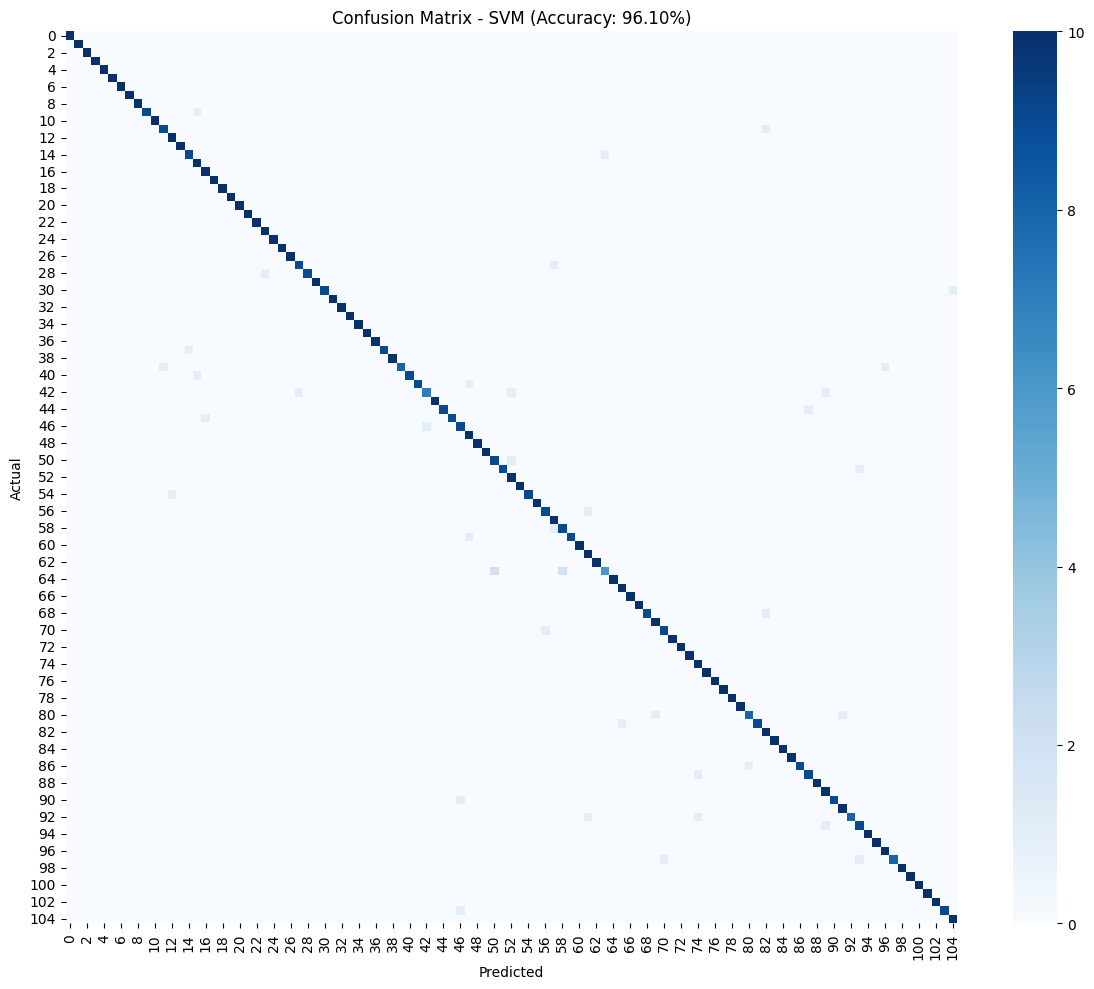

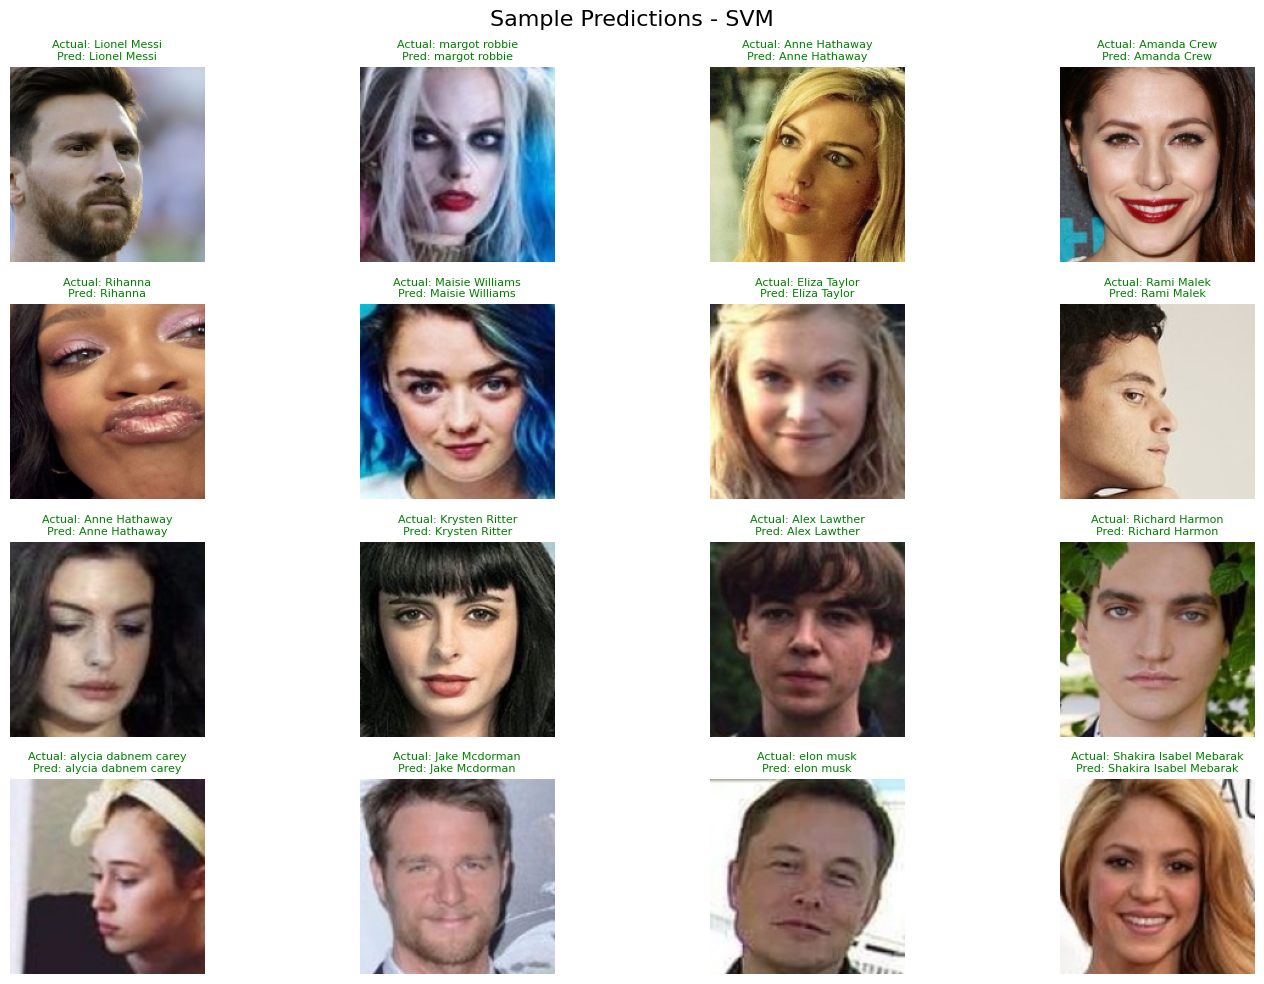


📊 Top 10 Classes by Accuracy:
 1. Adriana Lima        : 100.00%
 2. Alex Lawther        : 100.00%
 3. Alexandra Daddario  : 100.00%
 4. Alvaro Morte        : 100.00%
 5. Amanda Crew         : 100.00%
 6. Andy Samberg        : 100.00%
 7. Anne Hathaway       : 100.00%
 8. Anthony Mackie      : 100.00%
 9. Avril Lavigne       : 100.00%
10. Bill Gates          : 100.00%


In [7]:
# ===================================
# 4. Visualizing Results
# ===================================

print("📈 Generating visualizations...")

# Classification Report
print(f"\n📊 Classification Report for {model_name}:")
print(classification_report(y_test, best_pred, target_names=label_encoder.classes_))

# Confusion Matrix
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=False, cmap='Blues', fmt='d')
plt.title(f'Confusion Matrix - {model_name} (Accuracy: {best_acc*100:.2f}%)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Sample predictions visualization
plt.figure(figsize=(15, 10))
num_samples = 16
# Pastikan jumlah sampel tidak melebihi jumlah data di X_test
if len(X_test) < num_samples:
    num_samples = len(X_test)
random_indices = np.random.choice(len(X_test), num_samples, replace=False)

for i, idx in enumerate(random_indices):
    plt.subplot(4, 4, i + 1)

    # Get original image index by finding where the test embedding matches the full embeddings list
    # Note: This can be slow. For larger datasets, splitting indices is better.
    original_idx_arr = np.where(np.all(face_embeddings == X_test[idx], axis=1))
    if len(original_idx_arr[0]) > 0:
        original_idx = original_idx_arr[0][0]

        # === PERBAIKAN DI SINI ===
        # Ambil gambar yang sudah diproses
        img_processed = face_pixels[original_idx]

        # Denormalize (scale back to [0, 1] range) for visualization
        img_display = (img_processed - img_processed.min()) / (img_processed.max() - img_processed.min())

        # Tampilkan gambar yang sudah diskalakan kembali
        plt.imshow(img_display)
        # =========================

        # Get predictions
        actual = label_encoder.inverse_transform([y_test[idx]])[0]
        predicted = label_encoder.inverse_transform([best_pred[idx]])[0]

        # Set title with color coding
        color = 'green' if actual == predicted else 'red'
        plt.title(f'Actual: {actual.split("_")[-1]}\nPred: {predicted.split("_")[-1]}',
                 color=color, fontsize=8)

    plt.axis('off')

plt.suptitle(f'Sample Predictions - {model_name}', fontsize=16)
plt.tight_layout()
plt.show()

# Accuracy by class
class_accuracies = []
for class_idx in range(len(label_encoder.classes_)):
    class_mask = (y_test == class_idx)
    if np.sum(class_mask) > 0:
        class_acc = accuracy_score(y_test[class_mask], best_pred[class_mask])
        class_accuracies.append((label_encoder.classes_[class_idx], class_acc))

# Sort by accuracy
class_accuracies.sort(key=lambda x: x[1], reverse=True)

print("\n📊 Top 10 Classes by Accuracy:")
for i, (class_name, acc) in enumerate(class_accuracies[:10]):
    print(f"{i+1:2d}. {class_name.split('_')[-1]:20s}: {acc*100:.2f}%")





In [8]:
# ===================================
# 5. Save Models
# ===================================

print("💾 Saving trained models to Google Drive...")

# === PERUBAHAN: Gunakan output_files_path yang sudah didefinisikan ===

# Save best classifier
classifier_path = os.path.join(output_files_path, f'best_classifier_{model_name.lower().replace(" ", "_")}.pkl')
joblib.dump(best_model, classifier_path)
print(f"✅ Best classifier saved to: {classifier_path}")

# Save FaceNet model weights (ini adalah bobot 512D yang kita muat, jadi kita simpan ulang dengan nama standar kita)
facenet_weights_path = os.path.join(output_files_path, 'facenet_model_weights.weights.h5')
embeddings_generator.save_weights(facenet_weights_path)
print(f"✅ FaceNet weights saved to: {facenet_weights_path}")

# Save LabelEncoder
label_encoder_path = os.path.join(output_files_path, 'label_encoder.pkl')
joblib.dump(label_encoder, label_encoder_path)
print(f"✅ LabelEncoder saved to: {label_encoder_path}")

# Save Normalizer
normalizer_path = os.path.join(output_files_path, 'normalizer.pkl')
joblib.dump(normalizer, normalizer_path)
print(f"✅ Normalizer saved to: {normalizer_path}")

# Create and save known face embeddings for initial database
# (Kode ini bisa di-skip jika Anda menggunakan sistem registrasi di notebook inference)
# print("🔧 Creating known face embeddings for deployment...")
# ... (kode untuk membuat known_faces.npz) ...
# print(f"✅ Initial known faces data saved to: {known_faces_path}")


print("\n✅ All base models and data saved successfully to Google Drive!")

# =============================================================
# TAMBAHAN: Konversi Model ke TensorFlow Lite (TFLite)
# =============================================================
# Di titik ini, 'embeddings_generator' sudah pasti terdefinisi.

print("\n🚀 Memulai konversi model ke format TFLite...")

# Model yang akan dikonversi adalah embeddings_generator yang sudah ada di memori
model_to_convert = embeddings_generator

# A. Konversi ke TFLite Float32 (FP32)
print("🔧 Mengonversi ke TFLite FP32...")
converter_fp32 = tf.lite.TFLiteConverter.from_keras_model(model_to_convert)
tflite_model_fp32 = converter_fp32.convert()
tflite_fp32_path = os.path.join(output_files_path, 'facenet_fp32.tflite')
with open(tflite_fp32_path, 'wb') as f:
    f.write(tflite_model_fp32)
print(f"✅ Model TFLite FP32 disimpan di: {tflite_fp32_path} ({os.path.getsize(tflite_fp32_path) / 1e6:.2f} MB)")

# B. Konversi ke TFLite Float16 (FP16)
print("\n🔧 Mengonversi ke TFLite FP16...")
converter_fp16 = tf.lite.TFLiteConverter.from_keras_model(model_to_convert)
converter_fp16.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model_fp16 = converter_fp16.convert()
tflite_fp16_path = os.path.join(output_files_path, 'facenet_fp16.tflite')
with open(tflite_fp16_path, 'wb') as f:
    f.write(tflite_model_fp16)
print(f"✅ Model TFLite FP16 disimpan di: {tflite_fp16_path} ({os.path.getsize(tflite_fp16_path) / 1e6:.2f} MB)")

# C. Konversi ke TFLite Integer8 (INT8)
print("\n🔧 Mengonversi ke TFLite INT8...")
def representative_data_gen():
    # Ambil 200 sampel acak dari data training asli (sebelum diproses) untuk kalibrasi
    # 'face_pixels' berisi gambar-gambar yang sudah di-preprocess
    num_calibration_samples = 200
    # Pastikan jumlah sampel tidak melebihi data yang ada
    num_samples_to_take = min(num_calibration_samples, len(face_pixels))
    indices = np.random.choice(len(face_pixels), num_samples_to_take, replace=False)
    for i in indices:
        yield [np.expand_dims(face_pixels[i], axis=0).astype(np.float32)]

converter_int8 = tf.lite.TFLiteConverter.from_keras_model(model_to_convert)
converter_int8.optimizations = [tf.lite.Optimize.DEFAULT]
converter_int8.representative_dataset = representative_data_gen
converter_int8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_int8.inference_input_type = tf.float32 # Input tetap float32, internalnya jadi int8
converter_int8.inference_output_type = tf.float32 # Output tetap float32
tflite_model_int8 = converter_int8.convert()
tflite_int8_path = os.path.join(output_files_path, 'facenet_int8.tflite')
with open(tflite_int8_path, 'wb') as f:
    f.write(tflite_model_int8)
print(f"✅ Model TFLite INT8 disimpan di: {tflite_int8_path} ({os.path.getsize(tflite_int8_path) / 1e6:.2f} MB)")

print("\n🎉 Semua konversi TFLite selesai!")

💾 Saving trained models to Google Drive...
✅ Best classifier saved to: /content/drive/MyDrive/Magang KP Model AI /Output Files Facenet 512/best_classifier_svm.pkl
✅ FaceNet weights saved to: /content/drive/MyDrive/Magang KP Model AI /Output Files Facenet 512/facenet_model_weights.weights.h5
✅ LabelEncoder saved to: /content/drive/MyDrive/Magang KP Model AI /Output Files Facenet 512/label_encoder.pkl
✅ Normalizer saved to: /content/drive/MyDrive/Magang KP Model AI /Output Files Facenet 512/normalizer.pkl

✅ All base models and data saved successfully to Google Drive!

🚀 Memulai konversi model ke format TFLite...
🔧 Mengonversi ke TFLite FP32...
Saved artifact at '/tmp/tmpso39wr1i'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 512), dtype=tf.float32, name=None)
Captures:
  140438331021200: TensorSpec(shape=(), dtype=tf.resource, name